# 03 检查二维空间坐标
优先读取真实坐标表。若当前没有公开处理后坐标，则用明确标记的合成点验证绘图环境；合成图没有生物学含义。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
project = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
tables = list((project/'data/processed/coordinates').glob('*.csv')) + list((project/'data/processed/coordinates').glob('*.tsv'))
if tables:
    sep = '\t' if tables[0].suffix == '.tsv' else ','
    points = pd.read_csv(tables[0], sep=sep)
    lower = {c.lower(): c for c in points.columns}
    xcol, ycol = lower.get('x'), lower.get('y')
    if not xcol or not ycol: raise ValueError('坐标表没有可识别的 x/y 列')
    label = '真实本地坐标'
else:
    rng = np.random.default_rng(20240322)
    theta = rng.uniform(0, 2*np.pi, 1200)
    radius = np.sqrt(rng.uniform(0, 1, 1200))
    points = pd.DataFrame({'x': 2.3*radius*np.cos(theta), 'y': radius*np.sin(theta)})
    xcol, ycol, label = 'x', 'y', 'Synthetic test data (not a paper result)'
points.shape, label

D:\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


((1200, 2), 'Synthetic test data (not a paper result)')

WindowsPath('C:/Users/l/Documents/Codex/2026-08-15/github/spatial-omics-literature-data/papers/xiao-2024-human-gastrulation/results/figures/synthetic_test_coordinates_2d.png')

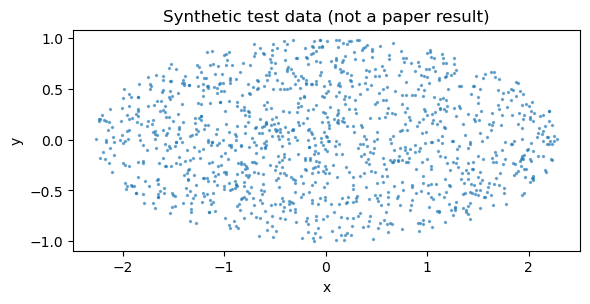

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(points[xcol], points[ycol], s=2, alpha=.55)
ax.set_aspect('equal')
ax.set_title(label)
ax.set_xlabel(xcol); ax.set_ylabel(ycol)
fig.tight_layout()
name = 'coordinates_2d.png' if tables else 'synthetic_test_coordinates_2d.png'
out = project/'results/figures'/name
fig.savefig(out, dpi=160)
out